## Trajectories

In [ ]:
import os, glob, re, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from math import ceil
from matplotlib.lines import Line2D


In [ ]:
SCENARIOS = [
    {"label": "normal",         "start": (-30, 7),   "goal": (-21.5, 17), "steps": 700},
    {"label": "uneven",         "start": (-30, -20), "goal": (-21.5, -6), "dz": -0.5, "steps": 700},
    
    # 1. UPDATED RAMP 
    {
        "label": "ramp",           
        "start": (-31, -44), 
        "goal": (-20, -37),  
        "steps": 700,
        "xlim": (-47, -34),   
        "ylim": (-35, 0)    
    },

    # 2. UPDATED CLIFF 
    {
        "label": "two_height_ramp",
        "start": (-55, 5),   
        "goal": (-41, 5),    
        "steps": 700,
        "xlim": (0, 16),      
        "ylim": (-57, -38)    
    },

    {
        "label": "ramp_obstacle",  
        "start": (-33, 40),  
        "goal": (-20, 40),   
        "steps": 700,
        "xlim": (25, 55),    
        "ylim": (-40, 0)   
    },
    
    # 3. FIXED HOLE (Derived from your image)
    {
        "label": "hole",           
        "start": (-55.2, -13),
        "goal": (-41, -13), 
        "dz": -4.5, 
        "steps": 700,
        "xlim": (-19, -11),   # Matches horizontal ticks (-17.5 to -12.5)
        "ylim": (-57, -39)    # Matches vertical ticks (-55 to -40)
    },
]

SCENARIO_SETTINGS = {item['label']: item for item in SCENARIOS}

[-29.98653221130371, 6.999813079833984] [-21.5, 17.0]
[-29.999998092651367, 7.0] [-21.5, 17.0]
[-29.999998092651367, 7.0] [-21.5, 17.0]
[-29.999998092651367, 7.0] [-21.5, 17.0]
[-29.999998092651367, 7.0] [-21.5, 17.0]
[-29.999998092651367, 7.0] [-21.5, 17.0]
[-29.999998092651367, 7.0] [-21.5, 17.0]
[-29.999998092651367, 7.0] [-21.5, 17.0]
[-29.999998092651367, 7.0] [-21.5, 17.0]
[-29.999998092651367, 7.0] [-21.5, 17.0]
[-29.999998092651367, 7.0] [-21.5, 17.0]
[-29.999998092651367, 7.0] [-21.5, 17.0]
[-29.999998092651367, 7.0] [-21.5, 17.0]
[-29.999998092651367, 7.0] [-21.5, 17.0]
[-29.999998092651367, 7.0] [-21.5, 17.0]
[-29.999998092651367, 7.0] [-21.5, 17.0]
[-29.999998092651367, 7.0] [-21.5, 17.0]
[-29.999998092651367, 7.0] [-21.5, 17.0]
[-29.999998092651367, 7.0] [-21.5, 17.0]
[-29.999998092651367, 7.0] [-21.5, 17.0]
[-30.01375961303711, -19.974184036254883] [-21.5, -6.0]
[-29.984323501586914, -19.942733764648438] [-21.5, -6.0]
[-29.98456573486328, -19.942867279052734] [-21.5, -6.0

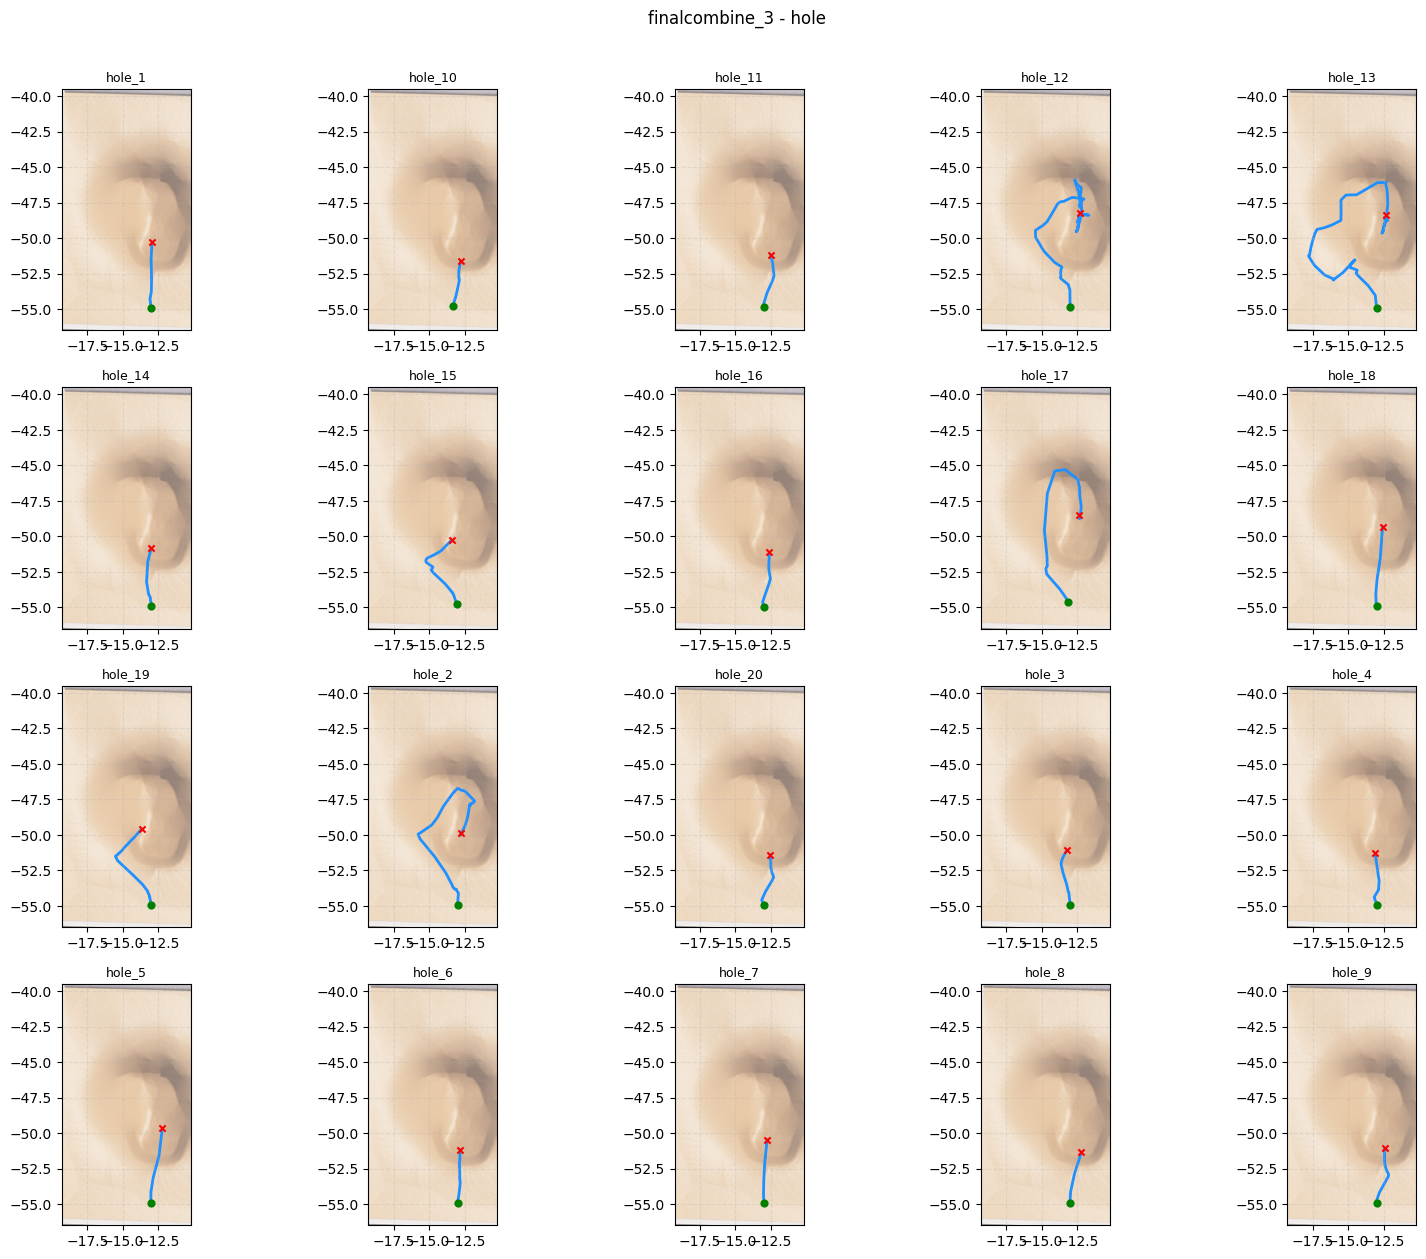

Saved: videos\finalcombine_3\trajectories_grid_1x5\normal_grid.png


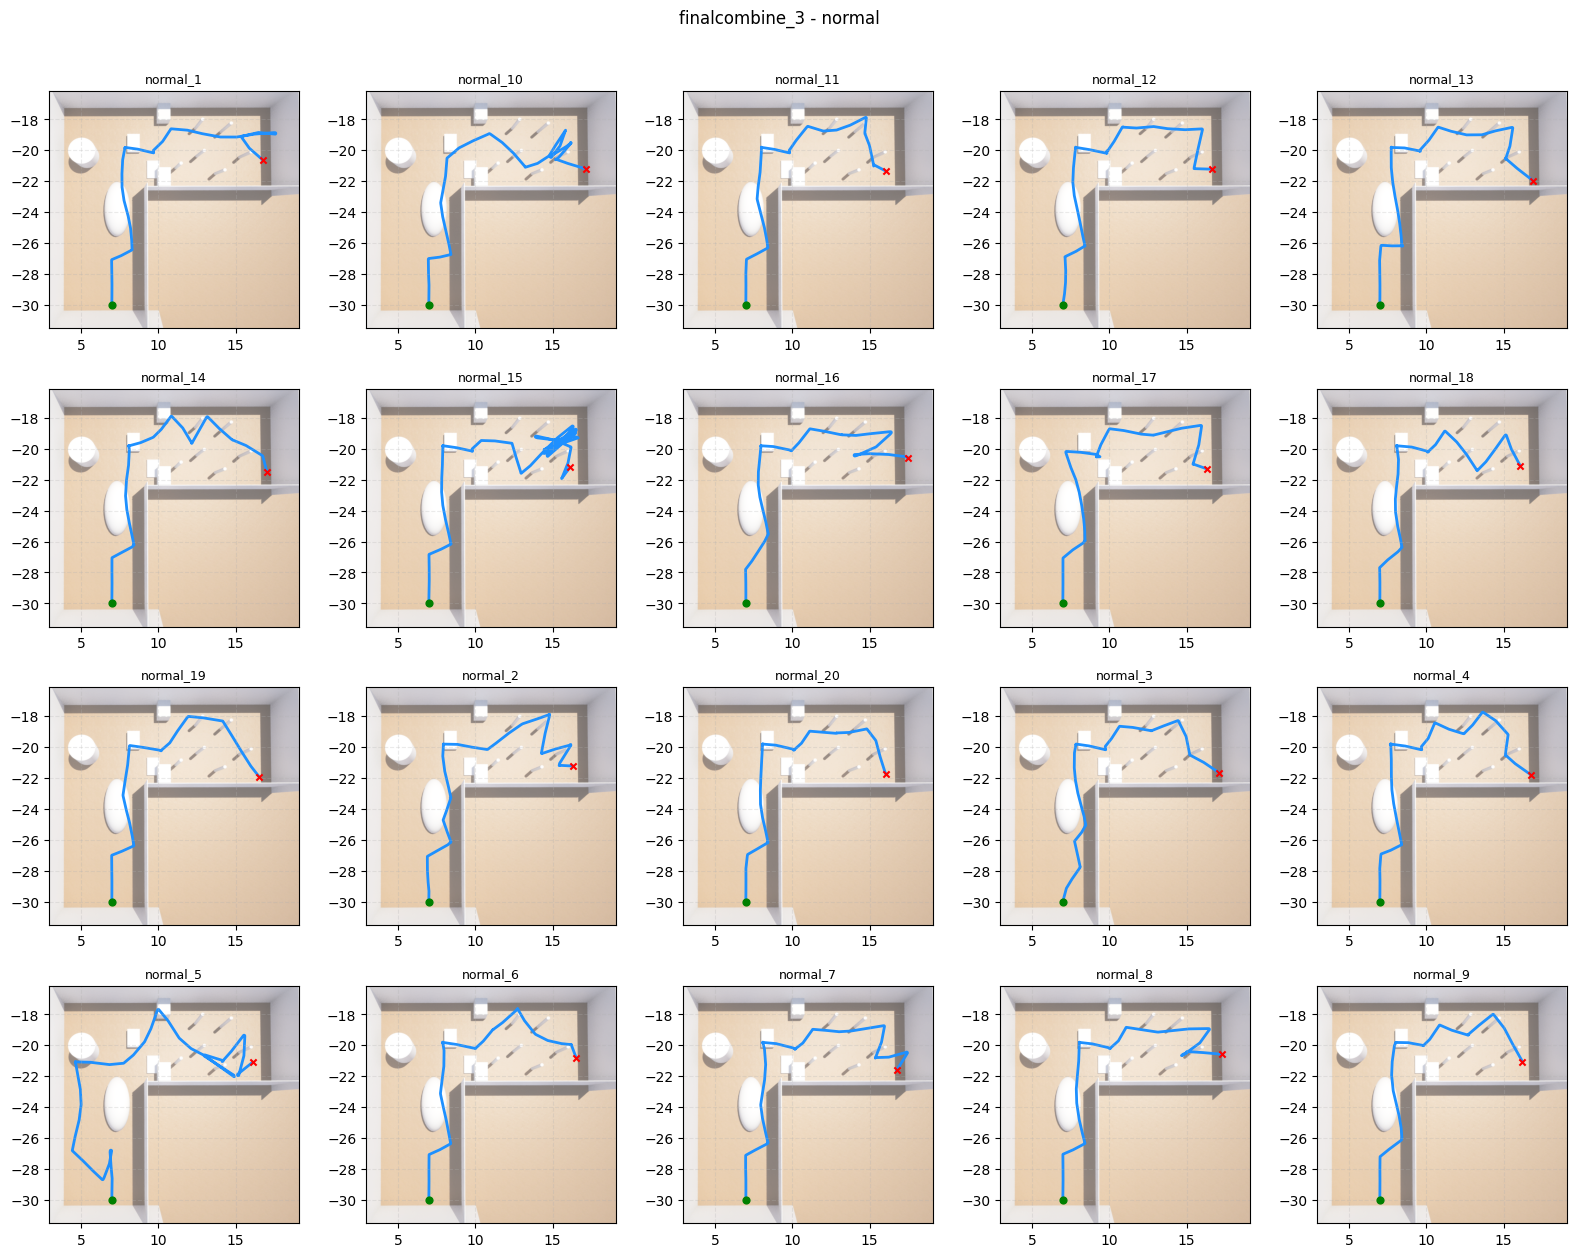

Saved: videos\finalcombine_3\trajectories_grid_1x5\ramp_grid.png


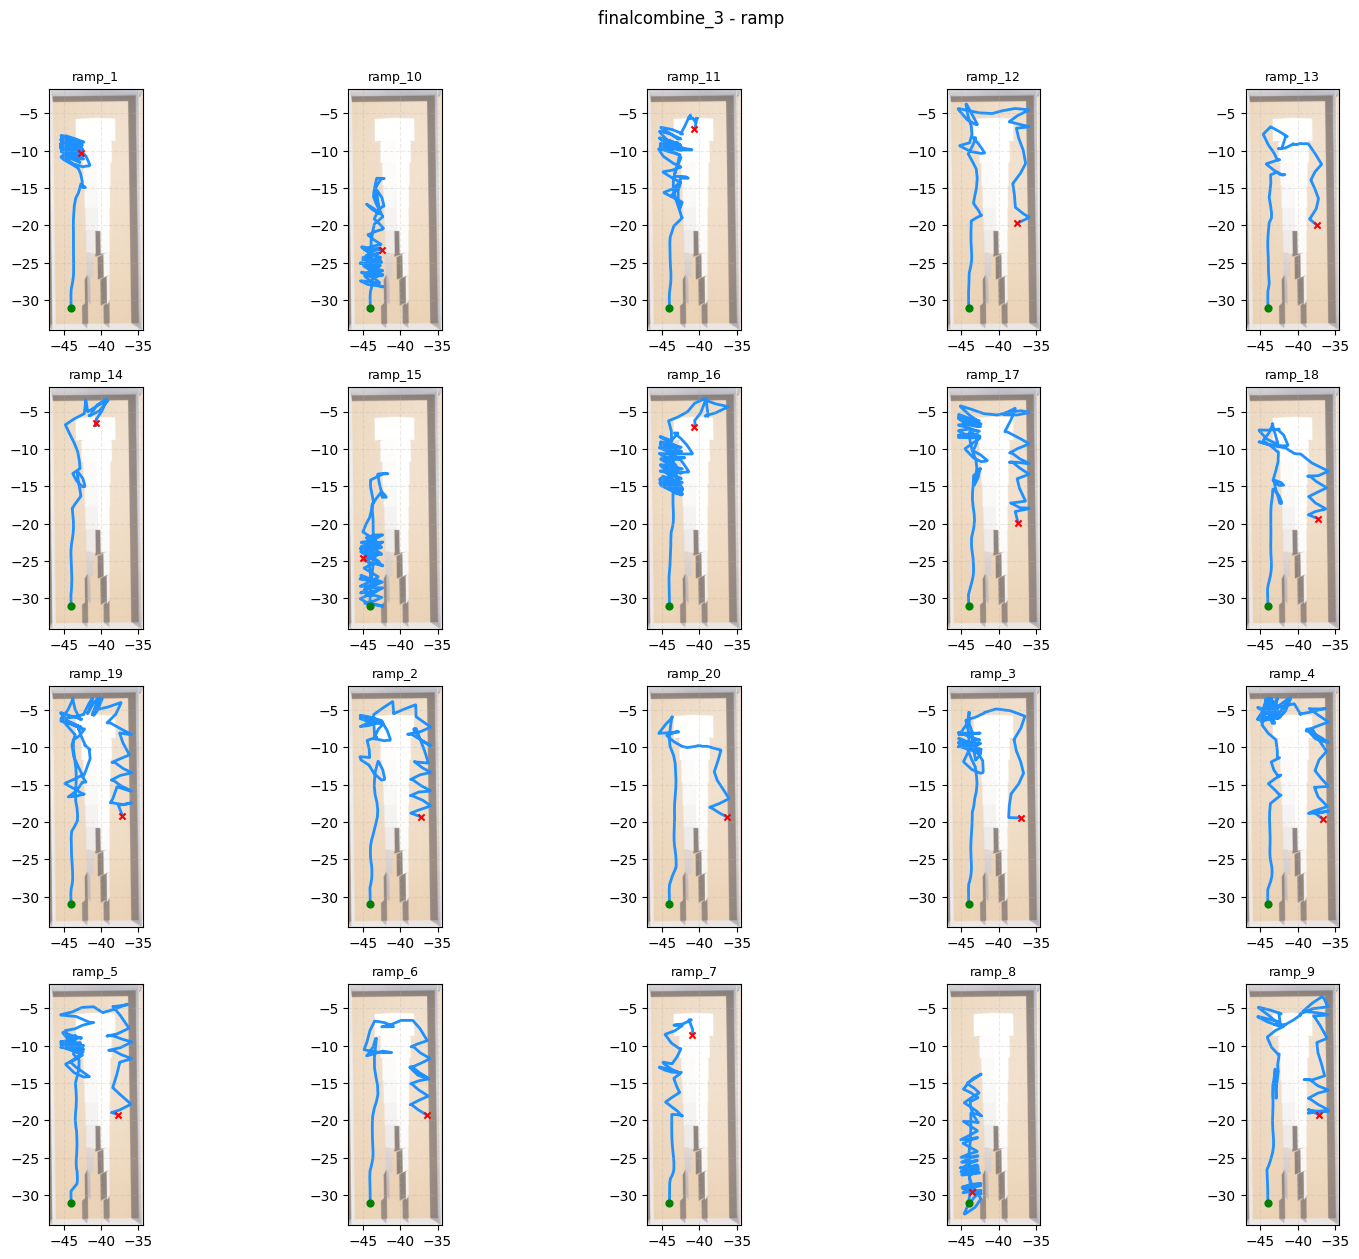

Saved: videos\finalcombine_3\trajectories_grid_1x5\ramp_obstacle_grid.png


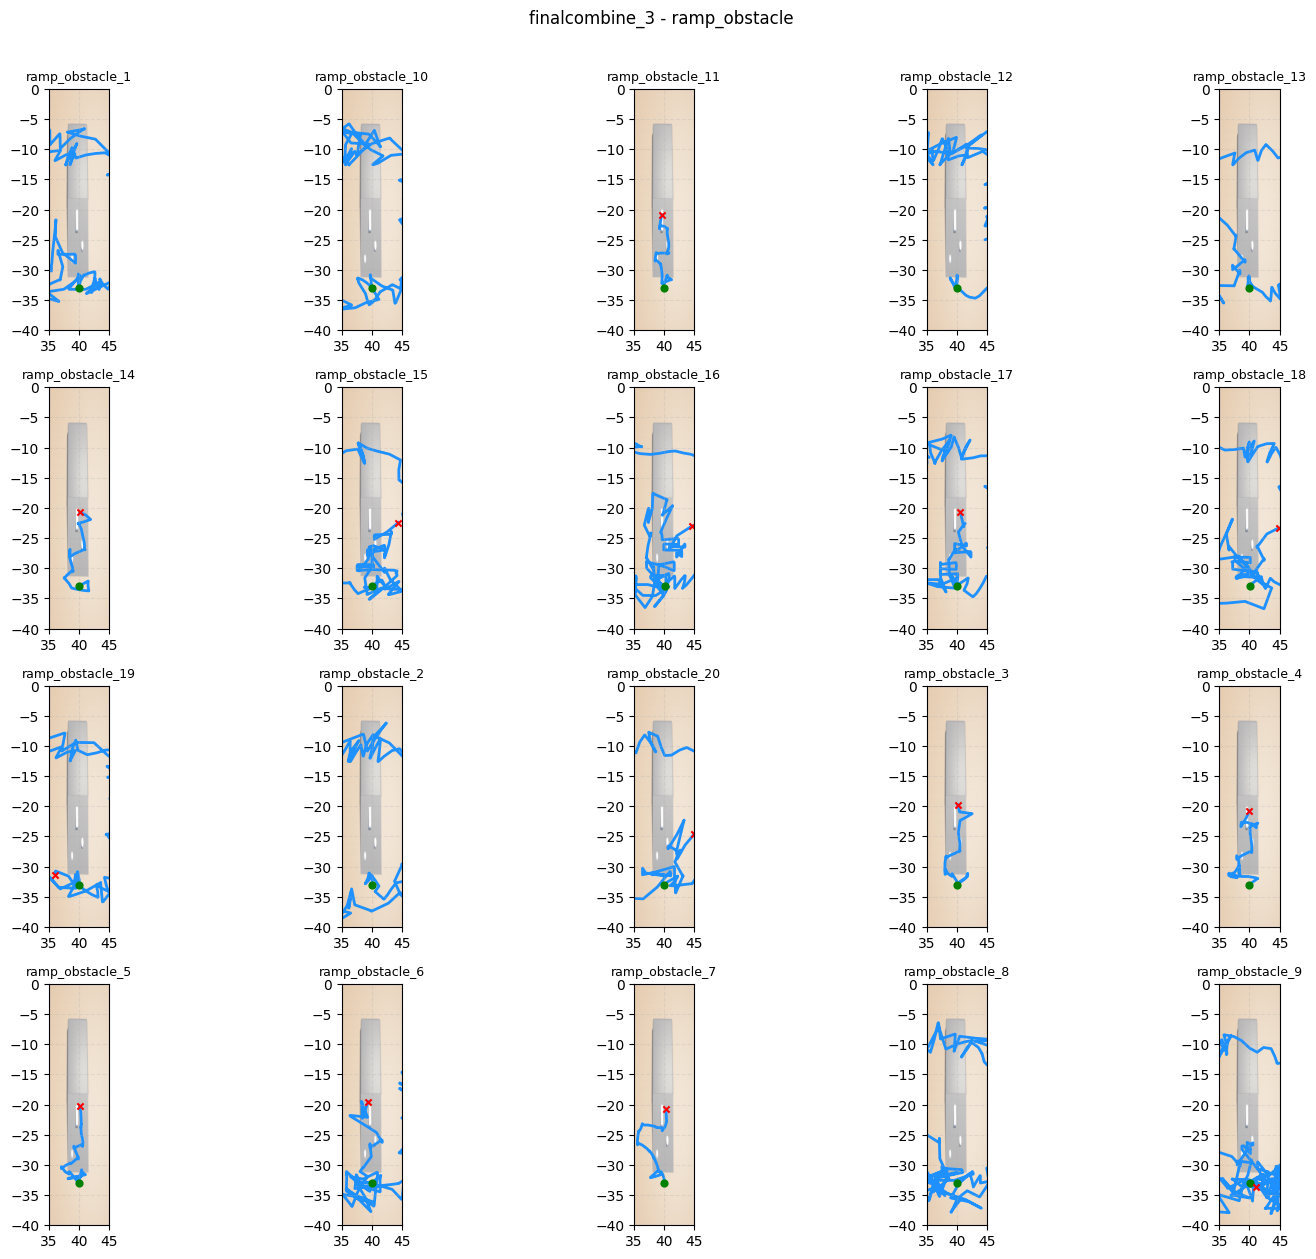

Saved: videos\finalcombine_3\trajectories_grid_1x5\two_height_ramp_grid.png


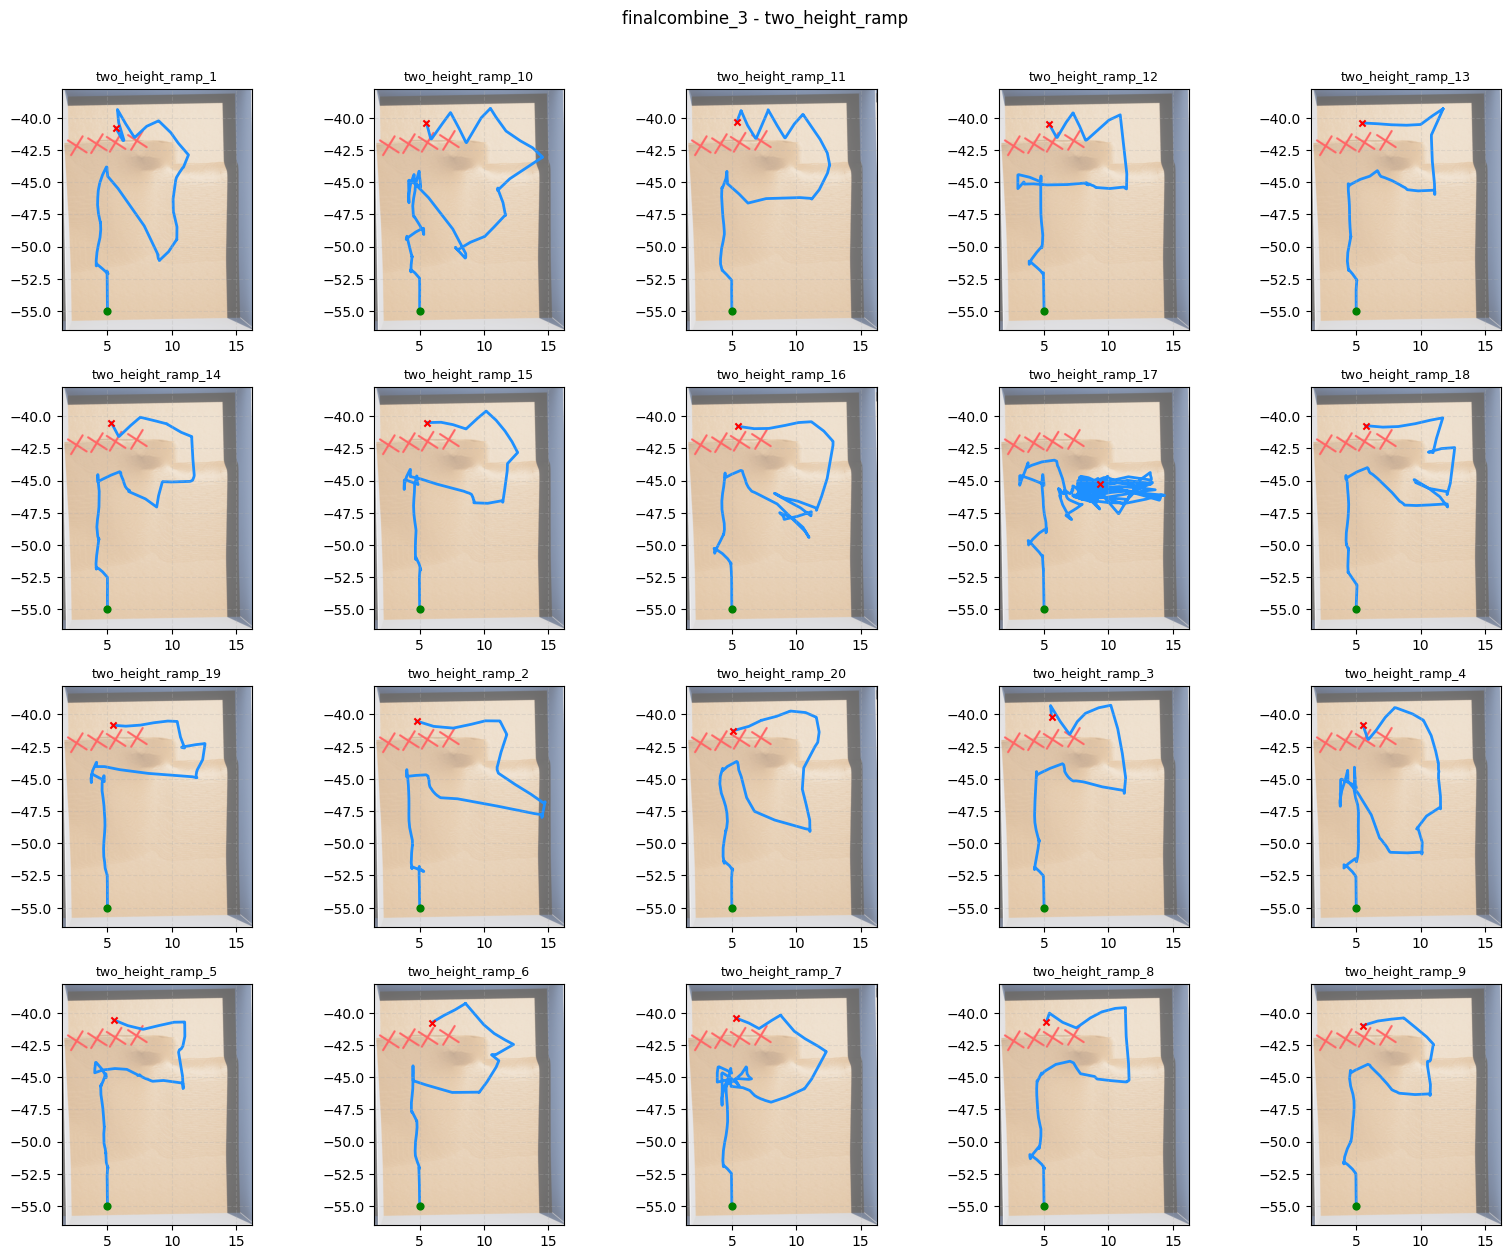

Saved: videos\finalcombine_3\trajectories_grid_1x5\uneven_grid.png


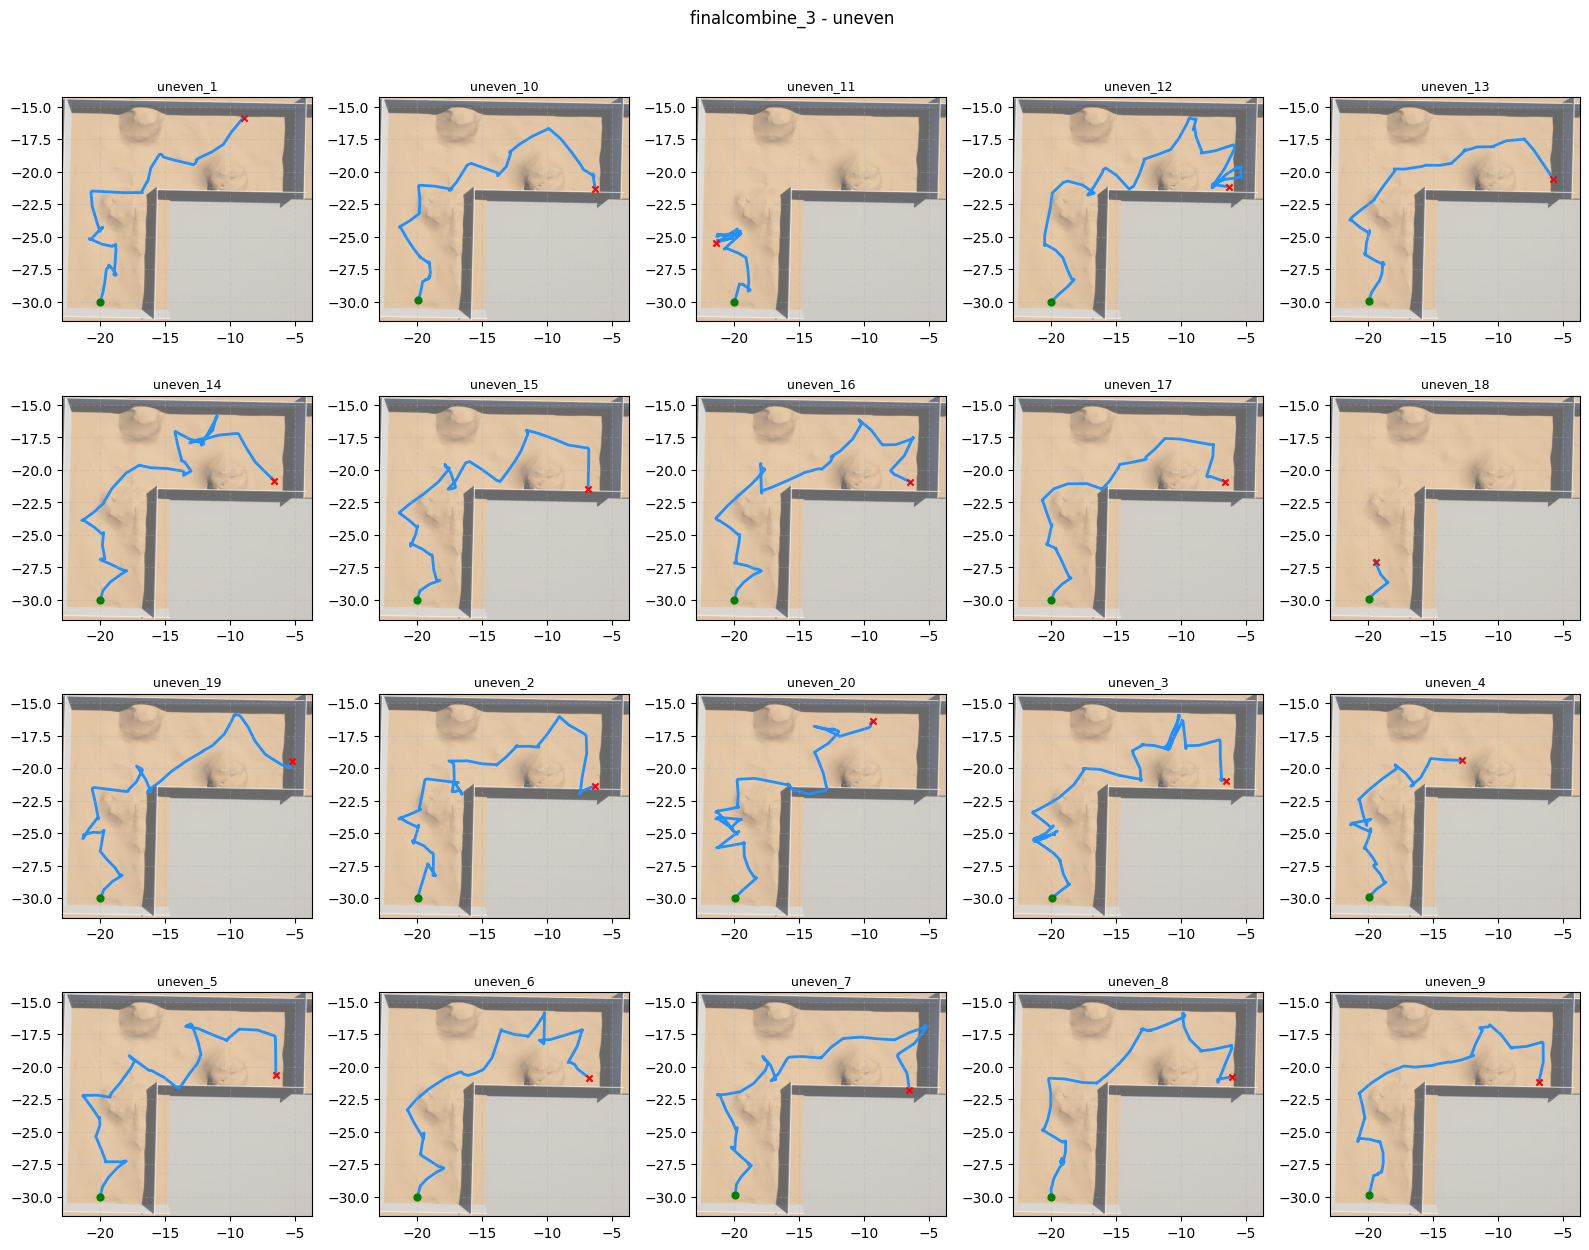

In [ ]:
# ===== settings =====
# Working dir should be PythonClient/car/trying/record
ROOTS = ['finalcombine_3'] # list of root folders to process (e.g., videos/finalcombine_3/, videos/finalcombine_4/, etc.)
MARGIN = 1.5      
SAVE_SUBDIR = 'trajectories_grid_1x5'   # save the trajectory grids under this subfolder in each root's folder (e.g., videos/finalcombine_3/trajectories_grid_1x5/)
BG_DIR = 'image'   # background images folder (e.g., image/hole.png)
BG_ALPHA = 0.6    
FLIP_BG_HORIZ = True
SHOW = True
COLS = 5          # keep columns fixed; rows will be derived from per-env max_n
# =====================

def round_pair(p):
    try:
        return (int(round(float(p[0]))), int(round(float(p[1]))))
    except Exception:
        return None
    
# Load goal map from stats file, keyed by rounded start point (x,y) -> rounded goal point (x,y)
def load_goal_map(stats_path):
    m = {}
    if not os.path.exists(stats_path):
        return m
    try:
        with open(stats_path, 'r') as fh:
            data = json.load(fh)
        for rec in data:
            sp = rec.get('start_point')
            gp = rec.get('goal_point')
            print(sp, gp)
            if isinstance(sp, (list, tuple)) and isinstance(gp, (list, tuple)) and len(sp) >= 2 and len(gp) >= 2:
                sp_key = round_pair(sp)
                gp_val = round_pair(gp)
                if sp_key and gp_val:
                    m[sp_key] = gp_val
    except Exception:
        pass
    return m

# Extract trajectory points from a run directory, sorted by index prefix in filename
def extract_idx(fn):
    base = os.path.splitext(fn)[0]
    try:
        return int(base.split('_')[0])
    except:
        return 10**12

# Load trajectory points from a run directory, sorted by index prefix in filename
def load_run_positions(run_dir):
    files = [f for f in os.listdir(run_dir) if f.lower().endswith('_car_state.json')]
    if not files:
        return np.empty((0, 2))
    files = sorted(files, key=extract_idx)
    xs, ys = [], []
    for f in files:
        fp = os.path.join(run_dir, f)
        try:
            with open(fp, 'r') as fh:
                data = json.load(fh)
            pos = data.get("kinematics_estimated", {}).get("position", {})
            xs.append(float(pos.get("x_val", np.nan)))
            ys.append(float(pos.get("y_val", np.nan)))
        except Exception:
            continue
    arr = np.array([xs, ys]).T
    return arr[~np.isnan(arr).any(axis=1)]

def base_env(name):
    m = re.match(r'^(.*?)(?:_\d+)?$', name)
    return m.group(1) if m else name

def bounds_with_margin(trajs, margin):
    all_pts = np.vstack(trajs)
    xmin, ymin = np.min(all_pts, axis=0)
    xmax, ymax = np.max(all_pts, axis=0)
    return (xmin - margin, xmax + margin, ymin - margin, ymax + margin)

def load_bg_image(env_name):
    path = os.path.join(BG_DIR, f'{env_name}.png')
    if os.path.exists(path):
        try:
            return mpimg.imread(path)
        except Exception:
            return None
    return None

# PREPASS: build per-env metadata 
env_meta = {}  # env_name -> {'max_n': int, 'bounds': (xmin,xmax,ymin,ymax)}

# Collect all trajectories + extra points per env to compute global bounds
env_points = {}  # env_name -> list of np arrays (N,2) to feed into bounds
for root_name in ROOTS:
    root = os.path.abspath(root_name)
    if not os.path.isdir(root):
        print(f'Root folder not found: {root}')
        continue

    # Per-root goal map (optional)
    stats_path = f'{root_name.split("_")[0]}_stats_3.json'
    GOAL_MAP = load_goal_map(stats_path) if os.path.exists(stats_path) else {}

    subdirs = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]
    groups = {}
    for sub in subdirs:
        groups.setdefault(base_env(sub), []).append(sub)

    # For each env under this root, load valid trajectories and update meta
    for env_name, runs in groups.items():
        trajs_this_root_env = []
        valid_count = 0
        for run in sorted(runs):
            run_dir = os.path.join(root, run)
            traj = load_run_positions(run_dir)
            if traj.shape[0] >= 2:
                trajs_this_root_env.append(traj)
                valid_count += 1

                # extra points from GOAL_MAP for better bounds (start/goal)
                x0, y0 = float(traj[0, 0]), float(traj[0, 1])
                s_key = round_pair((x0, y0))
                if s_key in GOAL_MAP:
                    gx, gy = GOAL_MAP[s_key]
                    trajs_this_root_env.append(np.array([[s_key[0], s_key[1]]], dtype=float))
                    trajs_this_root_env.append(np.array([[gx, gy]], dtype=float))

        # Update per-env max grid size
        meta = env_meta.setdefault(env_name, {'max_n': 0, 'bounds': None})
        if valid_count > meta['max_n']:
            meta['max_n'] = valid_count

        # Stash points for global bounds
        if trajs_this_root_env:
            env_points.setdefault(env_name, []).extend(trajs_this_root_env)

# Compute global bounds per env (shared across all roots)
# Create a lookup for custom scenario settings
SCENARIO_SETTINGS = {item['label']: item for item in SCENARIOS}

# Compute global bounds per env
for env_name, pts in env_points.items():
    settings = SCENARIO_SETTINGS.get(env_name, {})
    
    # Check if custom bounds are provided in the SCENARIOS list
    if "xlim" in settings and "ylim" in settings:
        # Use (xmin, xmax, ymin, ymax) format
        # Note: In your plot, xmin/xmax corresponds to Y data, ymin/ymax to X data
        custom_bounds = (settings["ylim"][0], settings["ylim"][1], 
                         settings["xlim"][0], settings["xlim"][1])
        env_meta[env_name]['bounds'] = custom_bounds
    else:
        # Fallback to automatic calculation
        xmin, xmax, ymin, ymax = bounds_with_margin(pts, MARGIN)
        env_meta[env_name]['bounds'] = (xmin, xmax, ymin, ymax)

# PASS 2: render each root using per-env constants
for root_name in ROOTS:
    root = os.path.abspath(root_name)
    if not os.path.isdir(root):
        print(f'Root folder not found: {root}')
        continue

    # Per-root goal map (optional)
    stats_path = f'{root_name.split("_")[0]}_stats_9.json'
    GOAL_MAP = load_goal_map(stats_path) if os.path.exists(stats_path) else {}
    # print(GOAL_MAP)
    subdirs = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]
    groups = {}
    for sub in subdirs:
        groups.setdefault(base_env(sub), []).append(sub)

    save_dir = os.path.join('videos', root_name, SAVE_SUBDIR)
    os.makedirs(save_dir, exist_ok=True)

    for env_name, runs in sorted(groups.items()):
        # Skip envs that had no points anywhere (no bounds)
        meta = env_meta.get(env_name, None)
        if not meta or not meta['bounds']:
            print(f"Skip (no global bounds): {root_name} / {env_name}")
            continue

        xmin, xmax, ymin, ymax = meta['bounds']
        max_n = meta['max_n']
        if max_n <= 0:
            print(f"Skip (no data anywhere): {root_name} / {env_name}")
            continue

        # Fixed grid per env across all roots
        cols = COLS
        rows = ceil(max_n / cols)

        # Preload background image once per env with consistent processing
        raw_bg = load_bg_image(env_name)
        if raw_bg is not None:
            bg_for_axes = np.flipud(raw_bg) if FLIP_BG_HORIZ else raw_bg
            img = bg_for_axes.astype(np.float32)
            if img.max() > 1.0:
                img /= 255.0
            img = np.clip(img * 1.1, 0.0, 1.0)
        else:
            img = None

        # Gather current root's trajectories (actual n may be < max_n)
        trajs, labels = [], []
        for run in sorted(runs):
            run_dir = os.path.join(root, run)
            traj = load_run_positions(run_dir)
            if traj.shape[0] >= 2:
                trajs.append(traj); labels.append(run)

        if not trajs:
            print(f"Skip (no data in this root): {root_name} / {env_name}")
            continue

        # Build figure with *per-env* consistent layout
        fig, axes = plt.subplots(rows, cols, figsize=(cols*3.2, rows*3.2), squeeze=False)
        plt.subplots_adjust(wspace=0.12, hspace=0.12)

        for i, (traj, label) in enumerate(zip(trajs, labels)):
            r, c = divmod(i, cols)
            ax = axes[r][c]

            # consistent bg image & extent across roots
            if img is not None:
                ax.imshow(img, extent=[ymin, ymax, xmin, xmax], origin='lower',
                          alpha=BG_ALPHA, zorder=0)

            x = traj[:, 0]; y = traj[:, 1]
            ax.plot(y, x, linewidth=2, color='dodgerblue', zorder=1)

            # start/goal markers (use GOAL_MAP if available)
            s_key = round_pair((x[0], y[0]))
            if s_key in GOAL_MAP:
                sx, sy = s_key
                gx, gy = GOAL_MAP[s_key]
                ax.scatter(sy, sx, c='green', s=24, zorder=2)            # start
                ax.scatter(gy, gx, c='black', s=40, marker='*', zorder=3)  # goal
            else:
                ax.scatter(y[0], x[0], c='green', s=24, zorder=2)

            ax.scatter(y[-1], x[-1], c='red', s=20, marker='x', zorder=2)  # end (orange/red)

            # Axes styling with global bounds
            ax.set_xlim(ymin, ymax)
            ax.set_ylim(xmin, xmax)
            ax.set_aspect('equal', adjustable='box')
            ax.grid(True, linestyle='--', alpha=0.25)
            ax.set_title(label, fontsize=9)

        # Hide any unused axes to preserve grid shape consistency
        n_actual = len(trajs)
        for j in range(n_actual, rows*cols):
            r, c = divmod(j, cols)
            axes[r][c].axis('off')

        fig.suptitle(f'{root_name} - {env_name} ', fontsize=12)
        fig.tight_layout(rect=[0, 0, 1, 0.97])

        out_path = os.path.join(save_dir, f'{env_name}_grid.png')
        fig.savefig(out_path, dpi=200, bbox_inches='tight')
        print(f"Saved: {out_path}")
        if SHOW:
            plt.show()
        else:
            plt.close(fig)


  -> Loading finalstep_3: Run 20
  -> Loading finalrandla_3: Run 7
  -> Loading finalmean_3: Run 19
  -> Loading finalcombine_3: Run 20
Saved Vector SVG to: videos/comparisons\comparison_two_height_ramp_hq.pdf


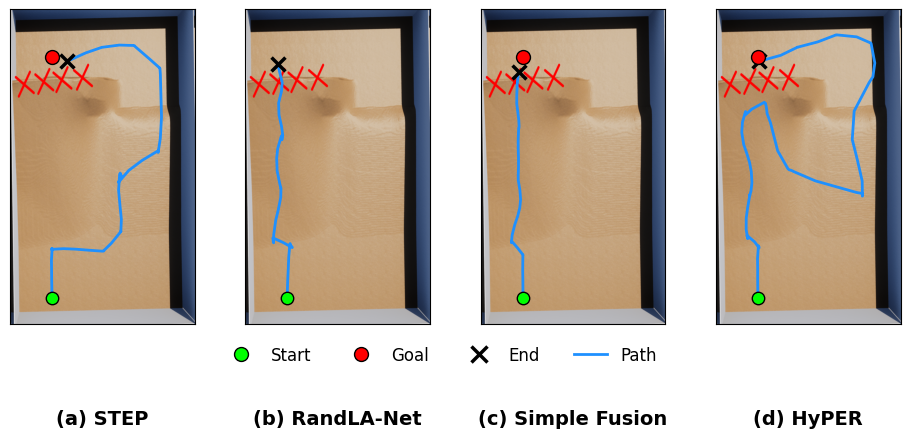

In [ ]:
# ===== settings =====
# Roots represent the methods (Columns)
ROOTS = ['finalstep_3', 'finalrandla_3', 'finalmean_3', 'finalcombine_3']
TARGET_ENV = 'two_height_ramp'

# CUSTOM HEADINGS & LABELS
CUSTOM_TITLES = ['STEP', 'RandLA-Net', 'Simple Fusion', 'HyPER']
BOTTOM_LABELS = ['(a)', '(b)', '(c)', '(d)']

# MAPPING CONFIGURATION
SOURCE_RUN_IDS = {
    'finalstep_3': 20,
    'finalrandla_3': 7,
    'finalmean_3': 19, 
    'finalcombine_3': 20
}

DISPLAY_ROW_ID = 20 

# Visualization settings
MARGIN = 1.5
SAVE_DIR = 'videos/comparisons'
BG_DIR = 'image'
BG_ALPHA = 1.0  # Opaque
SHOW = True
# =====================

def round_pair(p):
    try:
        return (int(round(float(p[0]))), int(round(float(p[1]))))
    except Exception:
        return None

def get_latest_stats_path(root_name):
    prefix = root_name.split("_")[0]
    files = glob.glob(f'{prefix}_stats_*.json')
    if not files: 
        return None
    return max(files, key=lambda f: int(re.search(r'_stats_(\d+)\.json$', f).group(1)))

def load_goal_map(stats_path):
    m = {}
    if not stats_path or not os.path.exists(stats_path):
        return m
    try:
        with open(stats_path, 'r') as fh:
            data = json.load(fh)
        for rec in data:
            sp = rec.get('start_point')
            gp = rec.get('goal_point')
            if isinstance(sp, (list, tuple)) and isinstance(gp, (list, tuple)):
                sp_key = round_pair(sp)
                gp_val = round_pair(gp)
                if sp_key and gp_val:
                    m[sp_key] = gp_val
    except Exception:
        pass
    return m

def extract_idx(fn):
    base = os.path.basename(fn)
    try:
        return int(base.split('_')[0])
    except:
        return -1

def load_run_positions(run_dir):
    files = [f for f in os.listdir(run_dir) if f.lower().endswith('_car_state.json')]
    if not files:
        return np.empty((0, 2))
    files = sorted(files, key=extract_idx)
    xs, ys = [], []
    for f in files:
        fp = os.path.join(run_dir, f)
        try:
            with open(fp, 'r') as fh:
                data = json.load(fh)
            pos = data.get("kinematics_estimated", {}).get("position", {})
            xs.append(float(pos.get("x_val", np.nan)))
            ys.append(float(pos.get("y_val", np.nan)))
        except Exception:
            continue
    arr = np.array([xs, ys]).T
    return arr[~np.isnan(arr).any(axis=1)]

def bounds_with_margin(trajs, margin):
    all_pts = np.vstack(trajs)
    xmin, ymin = np.min(all_pts, axis=0)
    xmax, ymax = np.max(all_pts, axis=0)
    return (xmin - margin, xmax + margin, ymin - margin, ymax + margin)

def load_bg_image(env_name):
    path = os.path.join(BG_DIR, f'{env_name}.png')
    if os.path.exists(path):
        try:
            return mpimg.imread(path)
        except Exception:
            return None
    return None

# ==========================================
print(f"Collecting specific runs for env: {TARGET_ENV}...")

run_data = {DISPLAY_ROW_ID: [None] * len(ROOTS)}
all_points = []

for m_idx, root_name in enumerate(ROOTS):
    root = os.path.abspath(root_name)
    if not os.path.isdir(root):
        print(f"Warning: {root} not found.")
        continue

    s_path = get_latest_stats_path(root_name)
    goal_map = load_goal_map(s_path)
    
    required_id = SOURCE_RUN_IDS.get(root_name, 20)
    target_folder_name = f"{TARGET_ENV}_{required_id}"
    
    full_path = os.path.join(root, target_folder_name)
    
    if os.path.exists(full_path) and os.path.isdir(full_path):
        print(f"  -> Loading {root_name}: Run {required_id}")
        traj = load_run_positions(full_path)
        
        if traj.shape[0] >= 2:
            run_data[DISPLAY_ROW_ID][m_idx] = {'traj': traj, 'gmap': goal_map, 'label': target_folder_name}
            all_points.append(traj)
            
            x0, y0 = traj[0]
            s_key = round_pair((x0, y0))
            if s_key in goal_map:
                gx, gy = goal_map[s_key]
                all_points.append(np.array([[gx, gy]]))
    else:
        print(f"  -> MISSING: {target_folder_name} in {root_name}")


if not all_points:
    print("No valid data found.")
    exit()

xmin, xmax, ymin, ymax = bounds_with_margin(all_points, MARGIN)
sorted_run_ids = [DISPLAY_ROW_ID] 
rows = len(sorted_run_ids)
cols = len(ROOTS)

raw_bg = load_bg_image(TARGET_ENV)
bg_img = None
if raw_bg is not None:
    # Vertical Flip ONLY
    bg_for_axes = np.flipud(raw_bg)
    bg_img = bg_for_axes.astype(np.float32)
    if bg_img.max() > 1.0: bg_img /= 255.0

# Increased figure height to fit everything nicely
fig, axes = plt.subplots(rows, cols, figsize=(cols*3.0, rows*5.0), squeeze=False)

# Increase bottom margin significantly (0.25) to fit Legend AND labels
plt.subplots_adjust(wspace=0.05, hspace=0.1, bottom=0.25) 

for r, run_id in enumerate(sorted_run_ids):
    for c, method_name in enumerate(ROOTS):
        ax = axes[r][c]
        data = run_data[run_id][c]
        
        ax.set_xlim(ymin, ymax)
        ax.set_ylim(xmin, xmax)
        ax.set_aspect('equal', adjustable='box')
        
        if bg_img is not None:
            ax.imshow(bg_img, extent=[ymin, ymax, xmin, xmax], origin='lower', alpha=BG_ALPHA, zorder=0)
            
        # Remove ticks and labels from axis
        ax.set_xticks([])
        ax.set_yticks([])
        bbox = ax.get_position()
        center_x = bbox.x0 + (bbox.width / 2)
        
        # Combine "(a)" with "STEP" -> "(a) STEP"
        full_label = f"{BOTTOM_LABELS[c]} {CUSTOM_TITLES[c]}"
        
        # Place label at the very bottom (y=0.05)
        fig.text(center_x, 0.05, full_label, fontsize=14, fontweight='bold', ha='center')

        if data:
            traj = data['traj']
            gmap = data['gmap']
            
            # Trajectory
            ax.plot(traj[:, 1], traj[:, 0], linewidth=2, color='dodgerblue', zorder=1)
            
            # Start/Goal Markers
            s_key = round_pair((traj[0, 0], traj[0, 1]))
            if s_key in gmap:
                sx, sy = s_key
                gx, gy = gmap[s_key]
                ax.scatter(sy, sx, c='lime', edgecolors='black', s=80, zorder=2)
                
                # Goal as RED DOT
                ax.scatter(gy, gx, c='red', edgecolors='black', marker='o', s=100, zorder=3)
            else:
                ax.scatter(traj[0, 1], traj[0, 0], c='lime', edgecolors='black', s=80, zorder=2)
            
            # End as BLACK X
            ax.scatter(traj[-1, 1], traj[-1, 0], c='black', s=100, marker='x', linewidths=2.5, zorder=2)

        else:
            ax.text(0.5, 0.5, 'N/A', transform=ax.transAxes, ha='center', va='center', alpha=0.3)

# 6. Global Legend (Placed ABOVE the labels)
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Start', markerfacecolor='lime', markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Goal', markerfacecolor='red', markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='x', color='w', label='End', markeredgecolor='black', markersize=12, markeredgewidth=2.5),
    Line2D([0], [0], color='dodgerblue', lw=2, label='Path')
]

# Position legend in the space between the plots and the text labels
# y=0.14 is above the labels at y=0.05
fig.legend(handles=legend_elements, loc='lower center', ncol=4, frameon=False, fontsize=12, bbox_to_anchor=(0.5, 0.14))

# Save
os.makedirs(SAVE_DIR, exist_ok=True)
out_path_png = os.path.join(SAVE_DIR, f'comparison_{TARGET_ENV}_hq.pdf')
# out_path_svg = os.path.join(SAVE_DIR, f'comparison_{TARGET_ENV}_hq.svg')

# Save SVG (Vector Graphics - Infinite Resolution for Text/Lines)
fig.savefig(out_path_png, format='pdf', bbox_inches='tight')
print(f"Saved Vector SVG to: {out_path_png}")

if SHOW:
    plt.show()
else:
    plt.close(fig)

  -> Loading finalstep_3: Run 1
  -> Loading finalrandla_3: Run 5
  -> Loading finalmean_3: Run 17
  -> Loading finalcombine_3: Run 12
Saved Vector SVG to: videos/comparisons\comparison_ramp.pdf


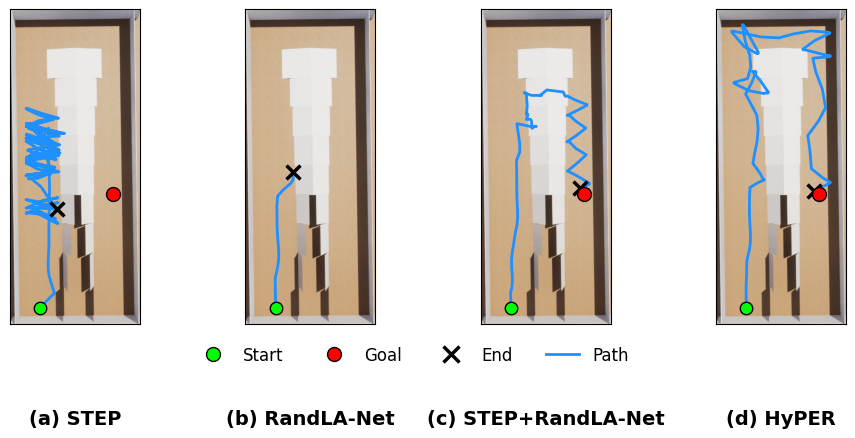

In [ ]:
# ===== settings =====
# Roots represent the methods (Columns)
ROOTS = ['finalstep_3', 'finalrandla_3', 'finalmean_3', 'finalcombine_3']
TARGET_ENV = 'ramp'

# CUSTOM HEADINGS & LABELS
CUSTOM_TITLES = ['STEP', 'RandLA-Net', 'STEP+RandLA-Net', 'HyPER']
BOTTOM_LABELS = ['(a)', '(b)', '(c)', '(d)']

# MAPPING CONFIGURATION 
SOURCE_RUN_IDS = {
    'finalstep_3': 1,
    'finalrandla_3': 5,
    'finalmean_3': 17, 
    'finalcombine_3': 12
}

# The ID we want to display them on in the plot
DISPLAY_ROW_ID = 20 

# Visualization settings
MARGIN = 1.5
SAVE_DIR = 'videos/comparisons'
BG_DIR = 'image'
BG_ALPHA = 1.0  # Opaque
SHOW = True
# =====================

def round_pair(p):
    try:
        return (int(round(float(p[0]))), int(round(float(p[1]))))
    except Exception:
        return None

def get_latest_stats_path(root_name):
    prefix = root_name.split("_")[0]
    files = glob.glob(f'{prefix}_stats_*.json')
    if not files: 
        return None
    return max(files, key=lambda f: int(re.search(r'_stats_(\d+)\.json$', f).group(1)))

def load_goal_map(stats_path):
    m = {}
    if not stats_path or not os.path.exists(stats_path):
        return m
    try:
        with open(stats_path, 'r') as fh:
            data = json.load(fh)
        for rec in data:
            sp = rec.get('start_point')
            gp = rec.get('goal_point')
            if isinstance(sp, (list, tuple)) and isinstance(gp, (list, tuple)):
                sp_key = round_pair(sp)
                gp_val = round_pair(gp)
                if sp_key and gp_val:
                    m[sp_key] = gp_val
    except Exception:
        pass
    return m

def extract_idx(fn):
    base = os.path.basename(fn)
    try:
        return int(base.split('_')[0])
    except:
        return -1

def load_run_positions(run_dir):
    files = [f for f in os.listdir(run_dir) if f.lower().endswith('_car_state.json')]
    if not files:
        return np.empty((0, 2))
    files = sorted(files, key=extract_idx)
    xs, ys = [], []
    for f in files:
        fp = os.path.join(run_dir, f)
        try:
            with open(fp, 'r') as fh:
                data = json.load(fh)
            pos = data.get("kinematics_estimated", {}).get("position", {})
            xs.append(float(pos.get("x_val", np.nan)))
            ys.append(float(pos.get("y_val", np.nan)))
        except Exception:
            continue
    arr = np.array([xs, ys]).T
    return arr[~np.isnan(arr).any(axis=1)]

def bounds_with_margin(trajs, margin):
    all_pts = np.vstack(trajs)
    xmin, ymin = np.min(all_pts, axis=0)
    xmax, ymax = np.max(all_pts, axis=0)
    return (xmin - margin, xmax + margin, ymin - margin, ymax + margin)

def load_bg_image(env_name):
    path = os.path.join(BG_DIR, f'{env_name}.png')
    if os.path.exists(path):
        try:
            return mpimg.imread(path)
        except Exception:
            return None
    return None

# ==========================================
print(f"Collecting specific runs for env: {TARGET_ENV}...")

run_data = {DISPLAY_ROW_ID: [None] * len(ROOTS)}
all_points = []

for m_idx, root_name in enumerate(ROOTS):
    root = os.path.abspath(root_name)
    if not os.path.isdir(root):
        print(f"Warning: {root} not found.")
        continue

    s_path = get_latest_stats_path(root_name)
    goal_map = load_goal_map(s_path)
    
    required_id = SOURCE_RUN_IDS.get(root_name, 20)
    target_folder_name = f"{TARGET_ENV}_{required_id}"
    
    full_path = os.path.join(root, target_folder_name)
    
    if os.path.exists(full_path) and os.path.isdir(full_path):
        print(f"  -> Loading {root_name}: Run {required_id}")
        traj = load_run_positions(full_path)
        
        if traj.shape[0] >= 2:
            run_data[DISPLAY_ROW_ID][m_idx] = {'traj': traj, 'gmap': goal_map, 'label': target_folder_name}
            all_points.append(traj)
            
            x0, y0 = traj[0]
            s_key = round_pair((x0, y0))
            if s_key in goal_map:
                gx, gy = goal_map[s_key]
                all_points.append(np.array([[gx, gy]]))
    else:
        print(f"  -> MISSING: {target_folder_name} in {root_name}")

# Global Bounds
if not all_points:
    print("No valid data found.")
    exit()

xmin, xmax, ymin, ymax = bounds_with_margin(all_points, MARGIN)

# Setup Grid
sorted_run_ids = [DISPLAY_ROW_ID] 
rows = len(sorted_run_ids)
cols = len(ROOTS)
raw_bg = load_bg_image(TARGET_ENV)
bg_img = None
if raw_bg is not None:
    # Vertical Flip ONLY
    bg_for_axes = np.flipud(raw_bg)
    bg_img = bg_for_axes.astype(np.float32)
    if bg_img.max() > 1.0: bg_img /= 255.0

# Plot
# Increased figure height to fit everything nicely
fig, axes = plt.subplots(rows, cols, figsize=(cols*3.0, rows*5.0), squeeze=False)

# Increase bottom margin significantly (0.25) to fit Legend AND labels
plt.subplots_adjust(wspace=0.05, hspace=0.1, bottom=0.25) 

for r, run_id in enumerate(sorted_run_ids):
    for c, method_name in enumerate(ROOTS):
        ax = axes[r][c]
        data = run_data[run_id][c]
        
        ax.set_xlim(ymin, ymax)
        ax.set_ylim(xmin, xmax)
        ax.set_aspect('equal', adjustable='box')
        
        if bg_img is not None:
            ax.imshow(bg_img, extent=[ymin, ymax, xmin, xmax], origin='lower', alpha=BG_ALPHA, zorder=0)
            
        # Remove ticks and labels from axis
        ax.set_xticks([])
        ax.set_yticks([])
        bbox = ax.get_position()
        center_x = bbox.x0 + (bbox.width / 2)
    
        full_label = f"{BOTTOM_LABELS[c]} {CUSTOM_TITLES[c]}"
        
        # Place label at the very bottom (y=0.05)
        fig.text(center_x, 0.05, full_label, fontsize=14, fontweight='bold', ha='center')

        if data:
            traj = data['traj']
            gmap = data['gmap']
            
            # Trajectory
            ax.plot(traj[:, 1], traj[:, 0], linewidth=2, color='dodgerblue', zorder=1)
            
            # Start/Goal Markers
            s_key = round_pair((traj[0, 0], traj[0, 1]))
            if s_key in gmap:
                sx, sy = s_key
                gx, gy = gmap[s_key]
                ax.scatter(sy, sx, c='lime', edgecolors='black', s=80, zorder=2)
                
                # Goal as RED DOT
                ax.scatter(gy, gx, c='red', edgecolors='black', marker='o', s=100, zorder=3)
            else:
                ax.scatter(traj[0, 1], traj[0, 0], c='lime', edgecolors='black', s=80, zorder=2)
            
            # End as BLACK X
            ax.scatter(traj[-1, 1], traj[-1, 0], c='black', s=100, marker='x', linewidths=2.5, zorder=2)

        else:
            ax.text(0.5, 0.5, 'N/A', transform=ax.transAxes, ha='center', va='center', alpha=0.3)

# Global Legend (Placed ABOVE the labels)
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Start', markerfacecolor='lime', markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Goal', markerfacecolor='red', markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='x', color='w', label='End', markeredgecolor='black', markersize=12, markeredgewidth=2.5),
    Line2D([0], [0], color='dodgerblue', lw=2, label='Path')
]

# Position legend in the space between the plots and the text labels
# y=0.14 is above the labels at y=0.05
fig.legend(handles=legend_elements, loc='lower center', ncol=4, frameon=False, fontsize=12, bbox_to_anchor=(0.5, 0.14))

# Save
os.makedirs(SAVE_DIR, exist_ok=True)
out_path_png = os.path.join(SAVE_DIR, f'comparison_{TARGET_ENV}.pdf')
# out_path_svg = os.path.join(SAVE_DIR, f'comparison_{TARGET_ENV}_hq.svg')

# Save SVG (Vector Graphics - Infinite Resolution for Text/Lines)
fig.savefig(out_path_png, format='pdf', bbox_inches='tight')
print(f"Saved Vector SVG to: {out_path_png}")

if SHOW:
    plt.show()
else:
    plt.close(fig)

  -> Loading finalstep_3: Run 16
  -> Loading finalrandla_3: Run 10
  -> Loading finalmean_3: Run 4
  -> Loading finalcombine_3: Run 17
Saved Vector SVG to: videos/comparisons\comparison_ramp_obstacle.pdf


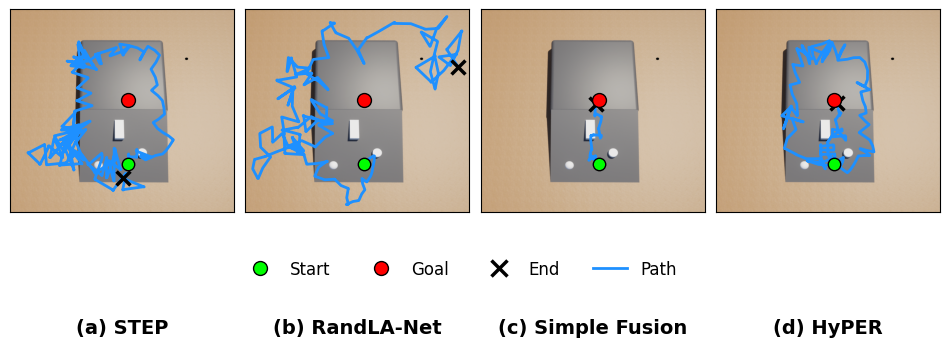

In [ ]:
# ===== settings =====
# Roots represent the methods (Columns)
ROOTS = ['finalstep_3', 'finalrandla_3', 'finalmean_3', 'finalcombine_3']
TARGET_ENV = 'ramp_obstacle'

# *** CUSTOM HEADINGS & LABELS ***
CUSTOM_TITLES = ['STEP', 'RandLA-Net', 'Simple Fusion', 'HyPER']
BOTTOM_LABELS = ['(a)', '(b)', '(c)', '(d)']

# *** MAPPING CONFIGURATION ***
SOURCE_RUN_IDS = {
    'finalstep_3': 16,
    'finalrandla_3': 10,
    'finalmean_3': 4, 
    'finalcombine_3': 17
}
DISPLAY_ROW_ID = 20 

# Visualization settings
MARGIN = 1.5
SAVE_DIR = 'videos/comparisons'
BG_DIR = 'image'
BG_ALPHA = 1.0  # Opaque
SHOW = True
# =====================

def round_pair(p):
    try:
        return (int(round(float(p[0]))), int(round(float(p[1]))))
    except Exception:
        return None

def get_latest_stats_path(root_name):
    prefix = root_name.split("_")[0]
    files = glob.glob(f'{prefix}_stats_*.json')
    if not files: 
        return None
    return max(files, key=lambda f: int(re.search(r'_stats_(\d+)\.json$', f).group(1)))

def load_goal_map(stats_path):
    m = {}
    if not stats_path or not os.path.exists(stats_path):
        return m
    try:
        with open(stats_path, 'r') as fh:
            data = json.load(fh)
        for rec in data:
            sp = rec.get('start_point')
            gp = rec.get('goal_point')
            if isinstance(sp, (list, tuple)) and isinstance(gp, (list, tuple)):
                sp_key = round_pair(sp)
                gp_val = round_pair(gp)
                if sp_key and gp_val:
                    m[sp_key] = gp_val
    except Exception:
        pass
    return m

def extract_idx(fn):
    base = os.path.basename(fn)
    try:
        return int(base.split('_')[0])
    except:
        return -1

def load_run_positions(run_dir):
    files = [f for f in os.listdir(run_dir) if f.lower().endswith('_car_state.json')]
    if not files:
        return np.empty((0, 2))
    files = sorted(files, key=extract_idx)
    xs, ys = [], []
    for f in files:
        fp = os.path.join(run_dir, f)
        try:
            with open(fp, 'r') as fh:
                data = json.load(fh)
            pos = data.get("kinematics_estimated", {}).get("position", {})
            xs.append(float(pos.get("x_val", np.nan)))
            ys.append(float(pos.get("y_val", np.nan)))
        except Exception:
            continue
    arr = np.array([xs, ys]).T
    return arr[~np.isnan(arr).any(axis=1)]

def bounds_with_margin(trajs, margin):
    all_pts = np.vstack(trajs)
    xmin, ymin = np.min(all_pts, axis=0)
    xmax, ymax = np.max(all_pts, axis=0)
    return (xmin - margin, xmax + margin, ymin - margin, ymax + margin)

def load_bg_image(env_name):
    path = os.path.join(BG_DIR, f'{env_name}.png')
    if os.path.exists(path):
        try:
            return mpimg.imread(path)
        except Exception:
            return None
    return None

# ==========================================
print(f"Collecting specific runs for env: {TARGET_ENV}...")

run_data = {DISPLAY_ROW_ID: [None] * len(ROOTS)}
all_points = []

for m_idx, root_name in enumerate(ROOTS):
    root = os.path.abspath(root_name)
    if not os.path.isdir(root):
        print(f"Warning: {root} not found.")
        continue

    s_path = get_latest_stats_path(root_name)
    goal_map = load_goal_map(s_path)
    
    required_id = SOURCE_RUN_IDS.get(root_name, 20)
    target_folder_name = f"{TARGET_ENV}_{required_id}"
    
    full_path = os.path.join(root, target_folder_name)
    
    if os.path.exists(full_path) and os.path.isdir(full_path):
        print(f"  -> Loading {root_name}: Run {required_id}")
        traj = load_run_positions(full_path)
        
        if traj.shape[0] >= 2:
            run_data[DISPLAY_ROW_ID][m_idx] = {'traj': traj, 'gmap': goal_map, 'label': target_folder_name}
            all_points.append(traj)
            
            x0, y0 = traj[0]
            s_key = round_pair((x0, y0))
            if s_key in goal_map:
                gx, gy = goal_map[s_key]
                all_points.append(np.array([[gx, gy]]))
    else:
        print(f"  -> MISSING: {target_folder_name} in {root_name}")

# Global Bounds
if not all_points:
    print("No valid data found.")
    exit()

xmin, xmax, ymin, ymax = bounds_with_margin(all_points, MARGIN)
sorted_run_ids = [DISPLAY_ROW_ID] 
rows = len(sorted_run_ids)
cols = len(ROOTS)

raw_bg = load_bg_image(TARGET_ENV)
bg_img = None
if raw_bg is not None:
    # Vertical Flip ONLY
    bg_for_axes = np.flipud(raw_bg)
    bg_img = bg_for_axes.astype(np.float32)
    if bg_img.max() > 1.0: bg_img /= 255.0

# Increased figure height to fit everything nicely
fig, axes = plt.subplots(rows, cols, figsize=(cols*3.0, rows*5.0), squeeze=False)

# Increase bottom margin significantly (0.25) to fit Legend AND labels
plt.subplots_adjust(wspace=0.05, hspace=0.1, bottom=0.25) 

for r, run_id in enumerate(sorted_run_ids):
    for c, method_name in enumerate(ROOTS):
        ax = axes[r][c]
        data = run_data[run_id][c]
        
        ax.set_xlim(ymin, ymax)
        ax.set_ylim(xmin, xmax)
        ax.set_aspect('equal', adjustable='box')
        
        if bg_img is not None:
            ax.imshow(bg_img, extent=[ymin, ymax, xmin, xmax], origin='lower', alpha=BG_ALPHA, zorder=0)
            
        # Remove ticks and labels from axis
        ax.set_xticks([])
        ax.set_yticks([])

        # Get the center X position of the current subplot
        bbox = ax.get_position()
        center_x = bbox.x0 + (bbox.width / 2)
        
        # Combine "(a)" with "STEP" -> "(a) STEP"
        full_label = f"{BOTTOM_LABELS[c]} {CUSTOM_TITLES[c]}"
        
        # Place label at the very bottom (y=0.05)
        fig.text(center_x, 0.12, full_label, fontsize=14, fontweight='bold', ha='center')

        if data:
            traj = data['traj']
            gmap = data['gmap']
            
            # Trajectory
            ax.plot(traj[:, 1], traj[:, 0], linewidth=2, color='dodgerblue', zorder=1)
            
            # Start/Goal Markers
            s_key = round_pair((traj[0, 0], traj[0, 1]))
            if s_key in gmap:
                sx, sy = s_key
                gx, gy = gmap[s_key]
                ax.scatter(sy, sx, c='lime', edgecolors='black', s=80, zorder=2)
                
                # Goal as RED DOT
                ax.scatter(gy, gx, c='red', edgecolors='black', marker='o', s=100, zorder=3)
            else:
                ax.scatter(traj[0, 1], traj[0, 0], c='lime', edgecolors='black', s=80, zorder=2)
            
            # End as BLACK X
            ax.scatter(traj[-1, 1], traj[-1, 0], c='black', s=100, marker='x', linewidths=2.5, zorder=2)

        else:
            ax.text(0.5, 0.5, 'N/A', transform=ax.transAxes, ha='center', va='center', alpha=0.3)

# 6. Global Legend (Placed ABOVE the labels)
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Start', markerfacecolor='lime', markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Goal', markerfacecolor='red', markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='x', color='w', label='End', markeredgecolor='black', markersize=12, markeredgewidth=2.5),
    Line2D([0], [0], color='dodgerblue', lw=2, label='Path')
]

# Position legend in the space between the plots and the text labels
# y=0.14 is above the labels at y=0.05
fig.legend(handles=legend_elements, loc='lower center', ncol=4, frameon=False, fontsize=12, bbox_to_anchor=(0.5, 0.20))

# 7. Save
os.makedirs(SAVE_DIR, exist_ok=True)
out_path_png = os.path.join(SAVE_DIR, f'comparison_{TARGET_ENV}.pdf')
# out_path_svg = os.path.join(SAVE_DIR, f'comparison_{TARGET_ENV}_hq.svg')

# Save SVG (Vector Graphics - Infinite Resolution for Text/Lines)
fig.savefig(out_path_png, format='pdf', bbox_inches='tight')
print(f"Saved Vector SVG to: {out_path_png}")

if SHOW:
    plt.show()
else:
    plt.close(fig)